# LISA Astrophysical Backgrounds (LAB) Walkthrough

This notebook guides you through running the calculation of the Astrophysical Gravitational Wave Background (AGWB) for a binary population of white dwarfs, and using the newly introduced `diagnostic` package to visualize the results.

## Learning Goals
1. Setup path environment to run the dev package.
2. Run the full calculation pipeline (Birth, Bulk, and Merger components).
3. Generate and display the premium diagnostic plots inside the notebook.

## 1. Environment Setup & Imports

We append the `src/` directory of the repository to our python path and change the working directory to the repository folder so that relative data paths resolve correctly.

In [1]:
import os
import sys

# Path to the repository folder
repo_dir = "/Users/jinhongming/mywork/LISA_astrophysics_WG/code/LISA_Astrophysical_Backgrounds-dev"
sys.path.insert(0, os.path.join(repo_dir, "src"))

# Change directory to the repository to resolve config dependencies
os.chdir(repo_dir)
print(f"Current working directory: {os.getcwd()}")

Current working directory: /Users/jinhongming/mywork/LISA_astrophysics_WG/code/LISA_Astrophysical_Backgrounds-dev


## 2. Run GWB Calculation Pipeline

We import `GravitationalWaveBackground` and run the simulation using `base_config.yaml`.

The metallicities of this population are None


GWB: 100%|██████████| 1/1 [00:02<00:00,  2.30s/batch]


Saving results at /Users/jinhongming/mywork/LISA_astrophysics_WG/code/LISA_Astrophysical_Backgrounds-dev/results
Saved population properties plot to /Users/jinhongming/mywork/LISA_astrophysics_WG/code/LISA_Astrophysical_Backgrounds-dev/results/diagnostic_population_mock_catalogue.png
Saved GWB spectrum plot to /Users/jinhongming/mywork/LISA_astrophysics_WG/code/LISA_Astrophysical_Backgrounds-dev/results/diagnostic_GWB_spectrum_mock_catalogue_with_madau_and_dickinson.png
Saved GWB redshift evolution plot to /Users/jinhongming/mywork/LISA_astrophysics_WG/code/LISA_Astrophysical_Backgrounds-dev/results/diagnostic_GWB_redshift_mock_catalogue.png
Saved SFRD vs Redshift plot to /Users/jinhongming/mywork/LISA_astrophysics_WG/code/LISA_Astrophysical_Backgrounds-dev/results/diagnostic_SFRD_madau_and_dickinson.png
Calculated GWB for 500 frequency bins.
Max GWB strength: 1.37e-11 at 9.02e-03 Hz


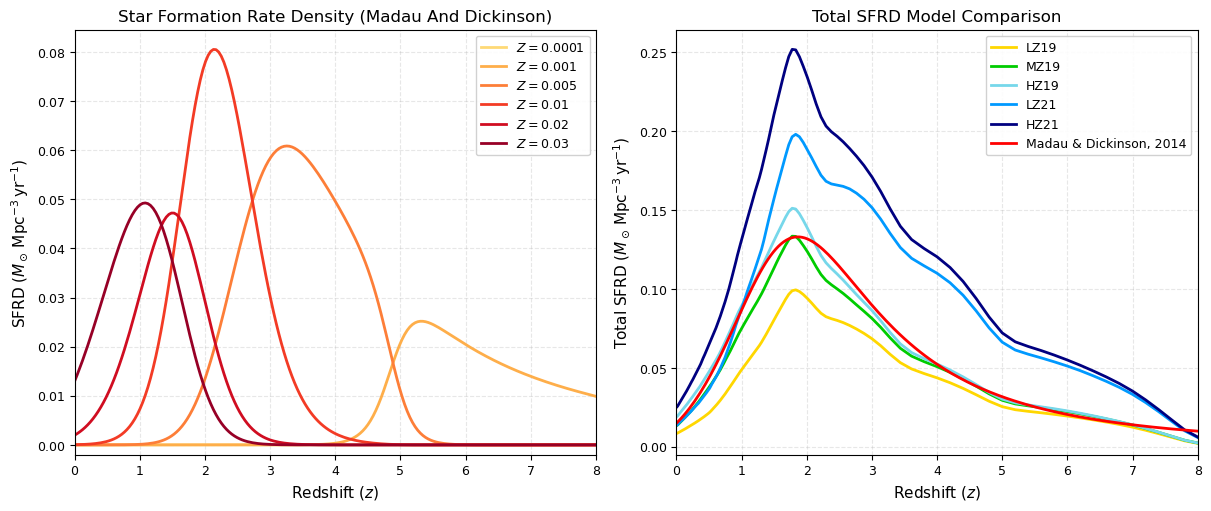

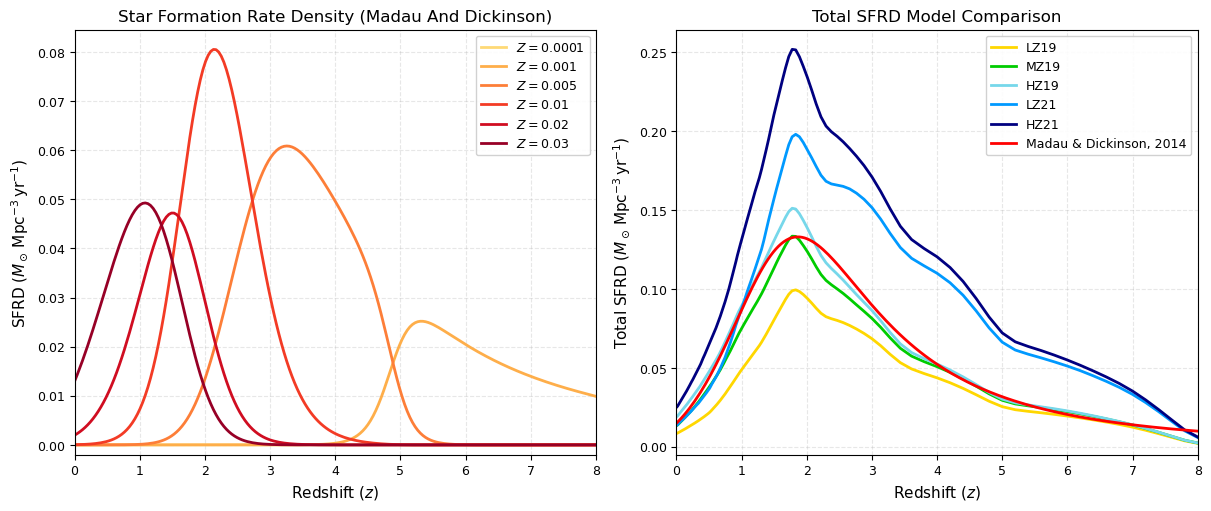

In [ ]:
from lisaastrophysicalbackgrounds.gravitational_wave_background import GravitationalWaveBackground
from lisaastrophysicalbackgrounds.diagnostic.plotting import plot_sfrd_vs_redshift

# 1. Initialize the GWB calculator with the configuration file
gwb = GravitationalWaveBackground('base_config.yaml')

# 2. Run the physical calculations (JAX kernels will be JIT-compiled on the first run)
gwb.calculate_GWB()

frequencies = gwb.f_vals
omega_gw = gwb.omega_f
num_sources = gwb.N_sources_f

print(f"Calculated GWB for {len(frequencies)} frequency bins.")
print(f"Max GWB strength: {omega_gw.max():.2e} at {frequencies[omega_gw.argmax()]:.2e} Hz")

# 3. Display the new 2-panel plot (left: metallicity breakdown of active model, right: total SFRD comparison)
# plot_sfrd_vs_redshift(gwb)



## 3. Visualize Diagnostics & GWB Evolution

We display the diagnostic plots generated by the pipeline directly inside the notebook. (These are saved automatically at the end of the simulation since `save_diagnostics: True` is enabled in `base_config.yaml`).

=== 1. Binary Population Diagnostics ===


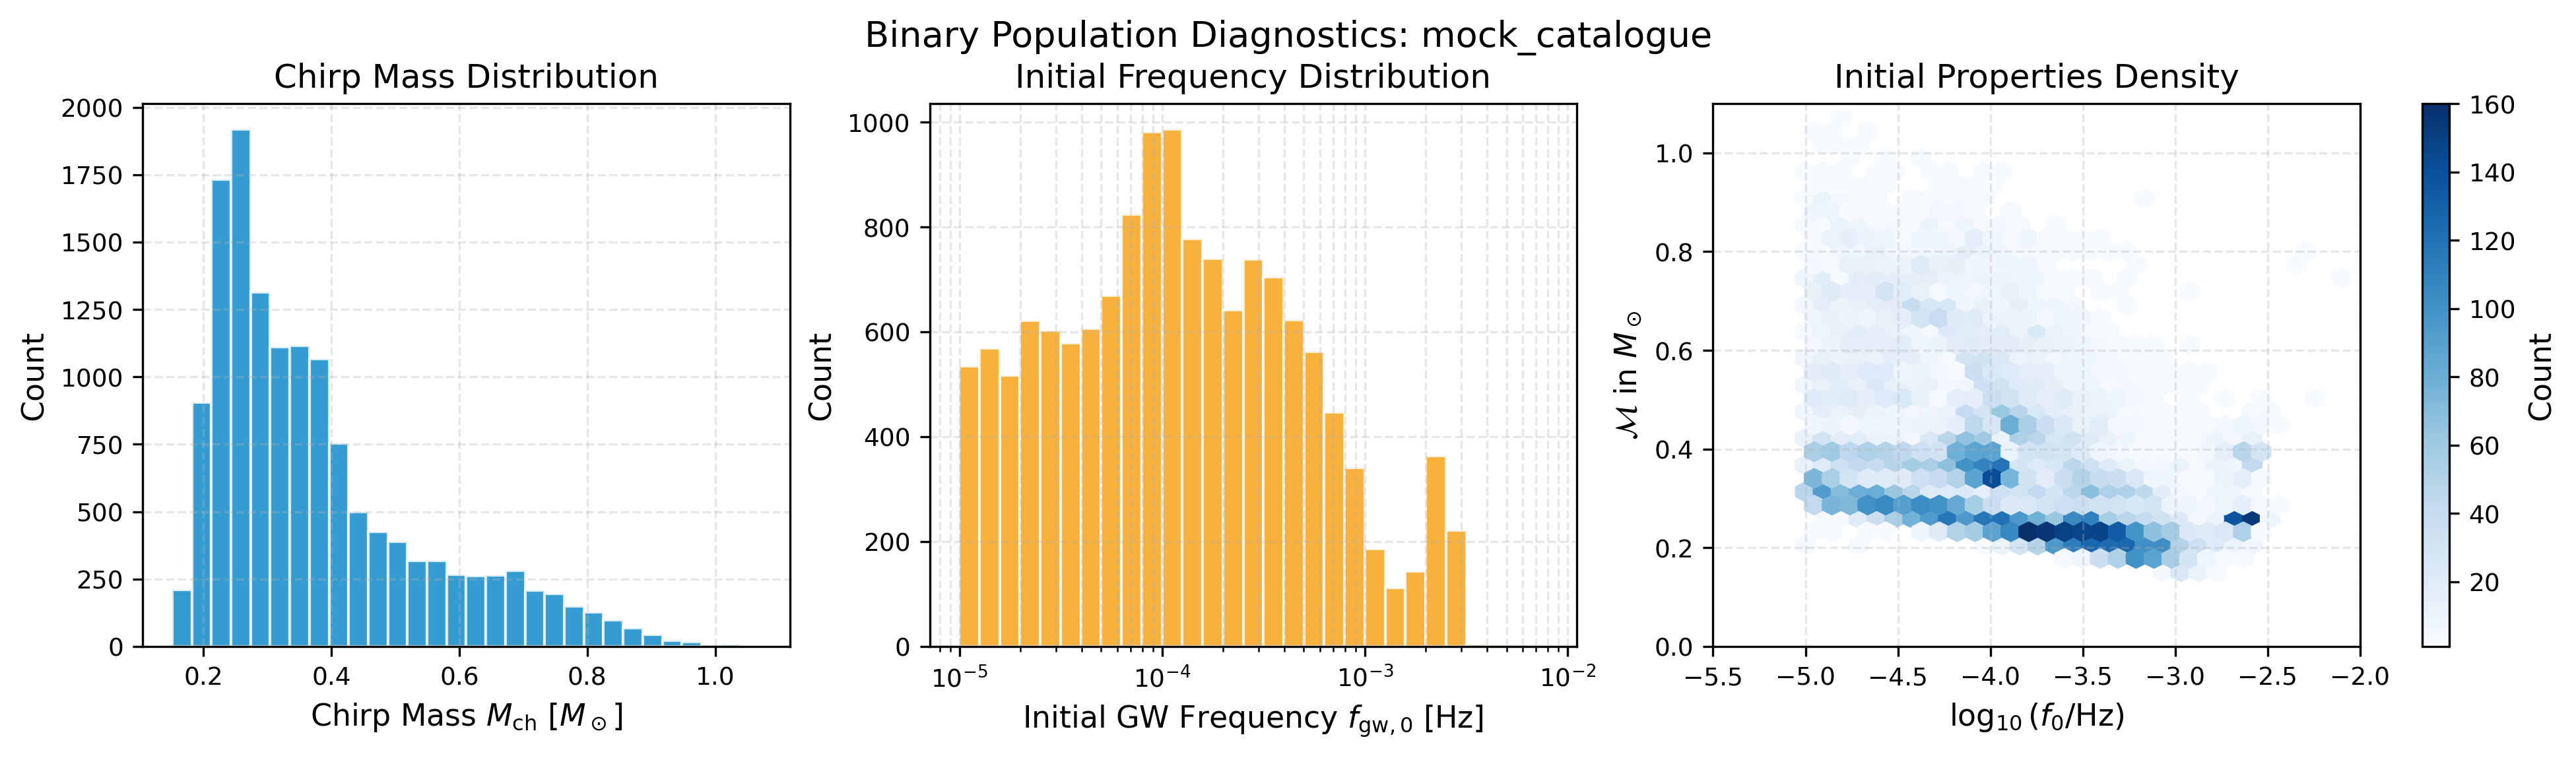


=== 2. GWB Component Breakdown ===


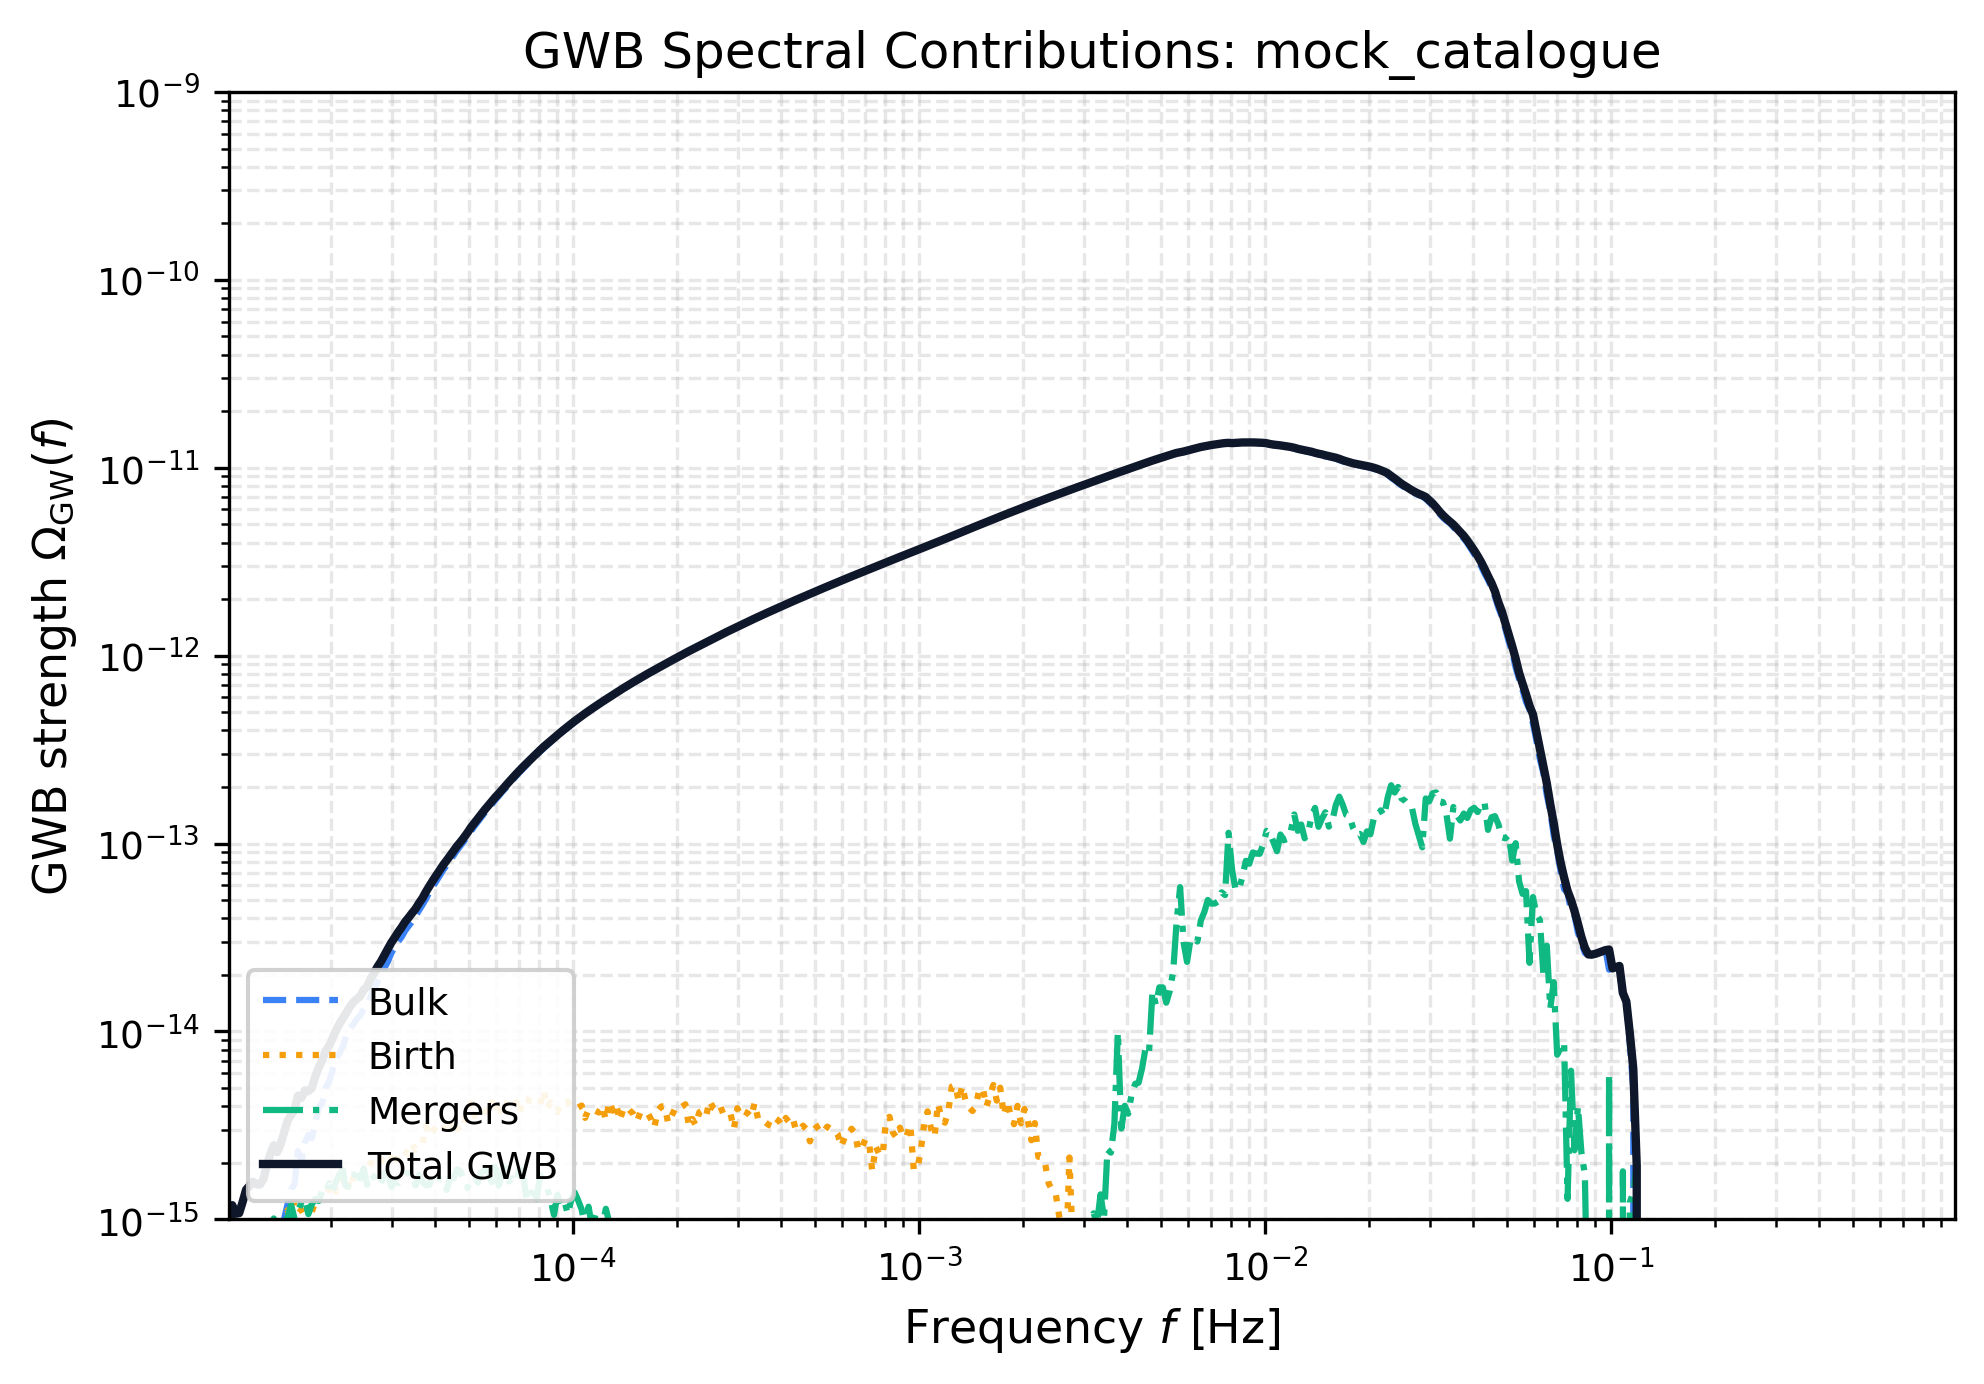


=== 3. GWB Redshift Evolution ===


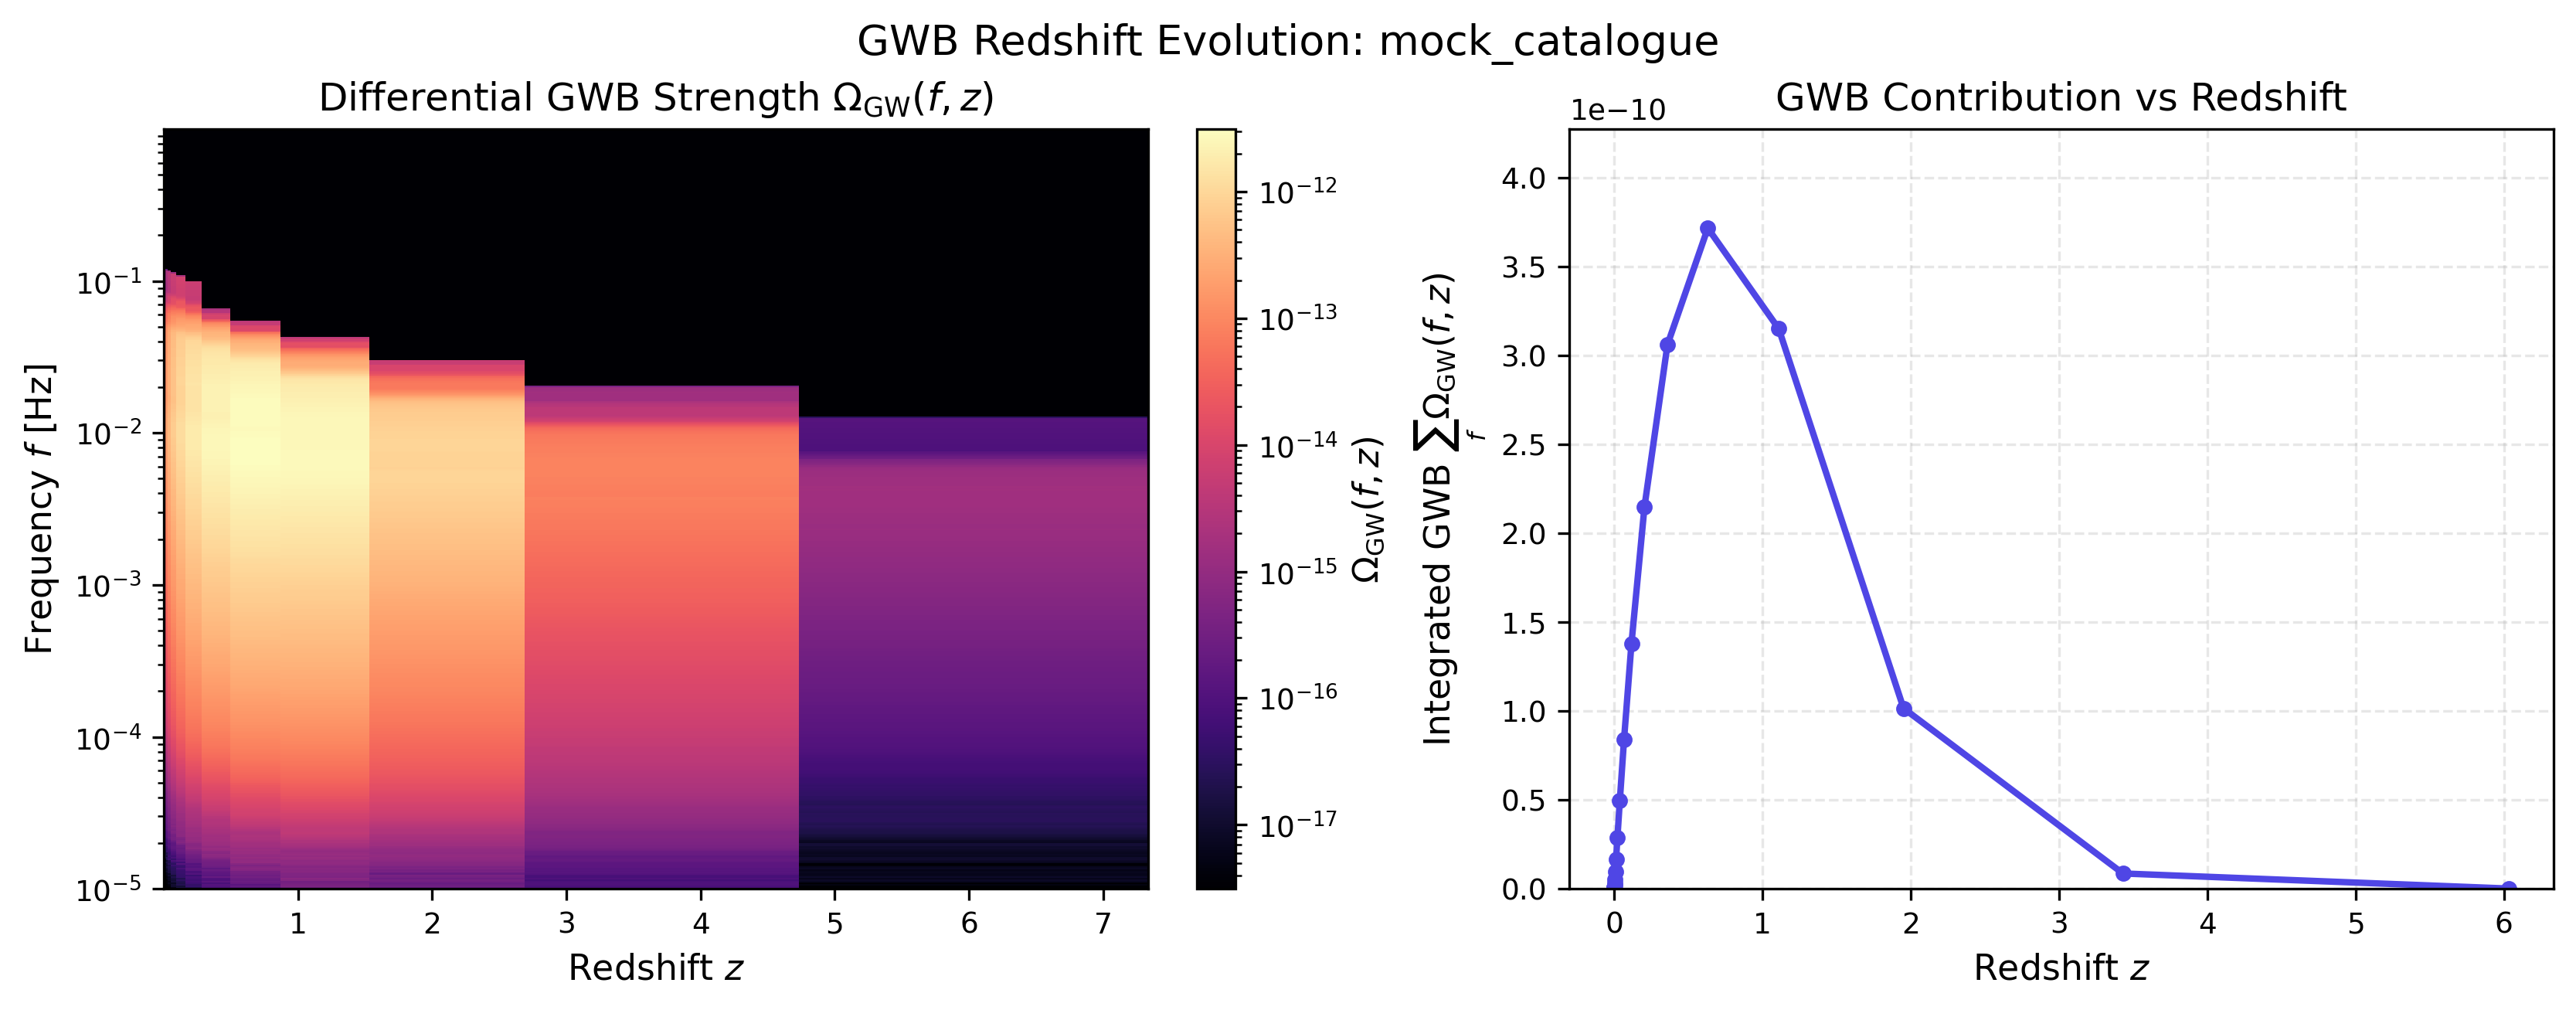


=== 4. Star Formation Rate Density ===


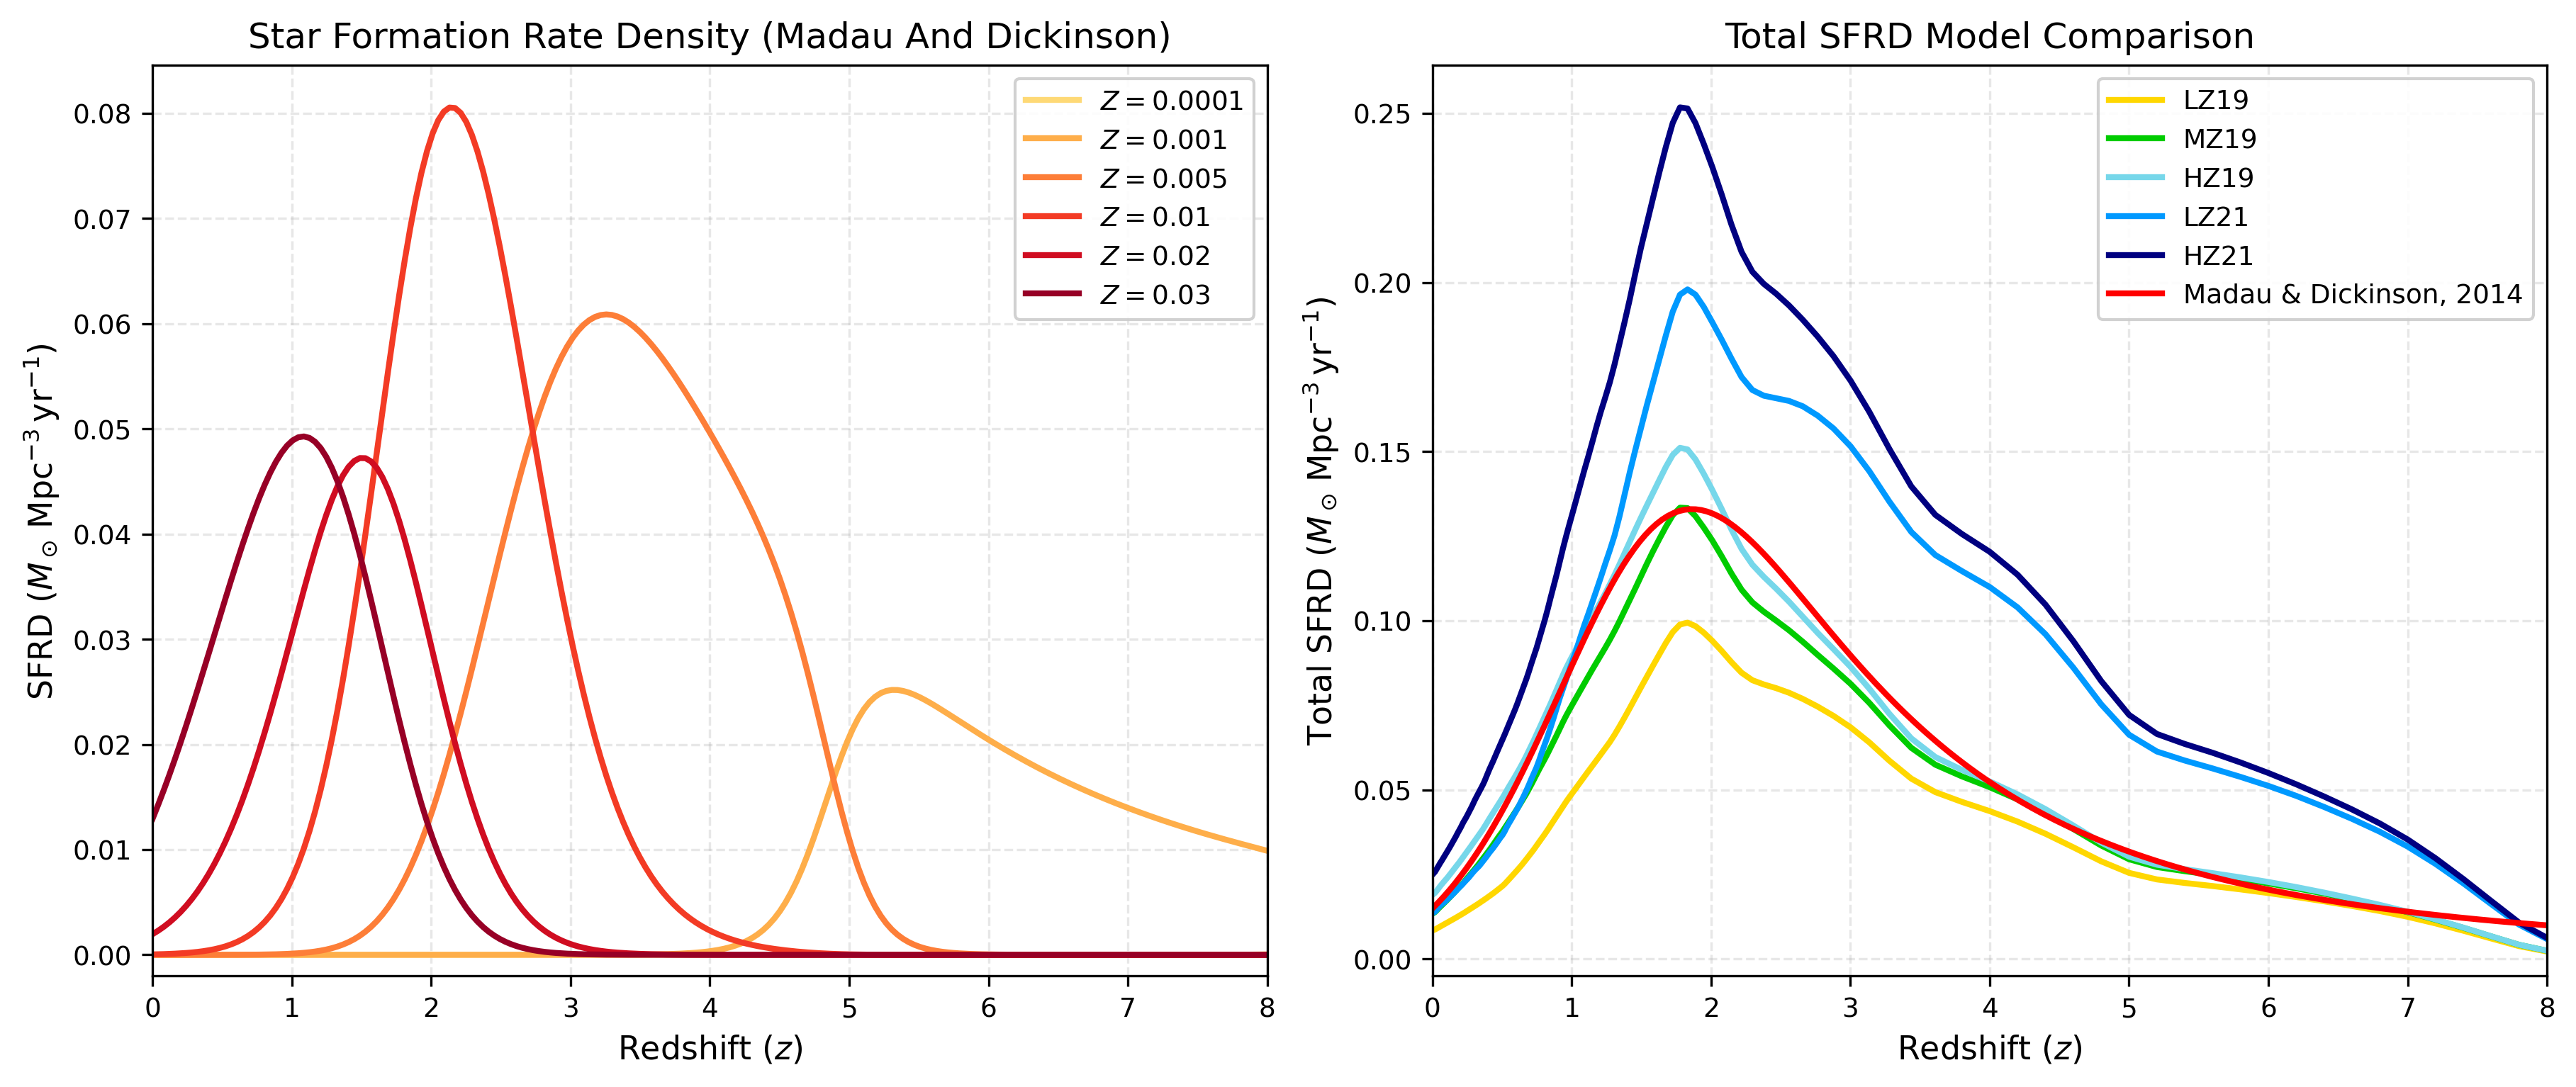

In [5]:
import os
from IPython.display import Image, display

# 1. Define paths and names
results_dir = os.path.join(repo_dir, "results")
pop_name = gwb.config["population"]["population_name"]
sfh_name = gwb.config["SFH"]["SFH_name"]

pop_plot_path = os.path.join(results_dir, f"diagnostic_population_{pop_name}.png")
spec_plot_path = os.path.join(results_dir, f"diagnostic_GWB_spectrum_{pop_name}_with_{sfh_name}.png")
redshift_plot_path = os.path.join(results_dir, f"diagnostic_GWB_redshift_{pop_name}.png")
sfrd_plot_path = os.path.join(results_dir, f"diagnostic_SFRD_{sfh_name}.png")

# 2. Display the diagnostic images sequentially
print("=== 1. Binary Population Diagnostics ===")
display(Image(filename=pop_plot_path))

print("\n=== 2. GWB Component Breakdown ===")
display(Image(filename=spec_plot_path))

print("\n=== 3. GWB Redshift Evolution ===")
display(Image(filename=redshift_plot_path))

print("\n=== 4. Star Formation Rate Density ===")
display(Image(filename=sfrd_plot_path))
